<a href="https://www.kaggle.com/code/alaynac/medical-symptom-to-disease-text-classifier?scriptVersionId=338897177" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/niyarrbarman/symptom2disease/Symptom2Disease.csv


# Final Project: Medical Symptom-to-Disease Text Classifier

## Overview
This project uses Natural Language Processing (NLP) to predict a likely
disease based on a patient's symptom description written in natural
language (e.g., "I have fever, headache, and body pain").

## Motivation
Many people describe their health concerns in everyday language rather
than medical terminology. This project bridges that gap by classifying
free-text symptom descriptions into 24 common disease categories,
demonstrating how NLP can support early symptom understanding.

## Dataset
**Symptom2Disease** (Kaggle) - contains 1,200 natural language symptom
descriptions labeled across 24 disease categories.

## Disclaimer
This model is built for educational purposes and is not a substitute
for professional medical diagnosis. Always consult a qualified doctor
for actual health concerns.

## Approach
1. Text preprocessing (cleaning, tokenization)
2. TF-IDF vectorization
3. Machine Learning classification (Logistic Regression)
4. Model evaluation (accuracy, confusion matrix)
5. Live prediction demo

## Step 1: Load Dataset

In [2]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/niyarrbarman/symptom2disease/Symptom2Disease.csv


## Step 2: Explore the Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/niyarrbarman/symptom2disease/Symptom2Disease.csv')

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nNumber of unique diseases:", df['label'].nunique())
print("\nDisease categories:")
print(df['label'].unique())

print("\nSamples per disease:")
print(df['label'].value_counts())

Dataset shape: (1200, 3)

Columns: ['Unnamed: 0', 'label', 'text']

First 5 rows:
   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...

Number of unique diseases: 24

Disease categories:
['Psoriasis' 'Varicose Veins' 'Typhoid' 'Chicken pox' 'Impetigo' 'Dengue'
 'Fungal infection' 'Common Cold' 'Pneumonia' 'Dimorphic Hemorrhoids'
 'Arthritis' 'Acne' 'Bronchial Asthma' 'Hypertension' 'Migraine'
 'Cervical spondylosis' 'Jaundice' 'Malaria' 'urinary tract infection'
 'allergy' 'gastroesophageal reflux disease' 'drug reaction'
 'peptic ulcer disease' 'diabetes']

Samples per disease:
label
Psori

## Step 3: Visualize Class Distribution

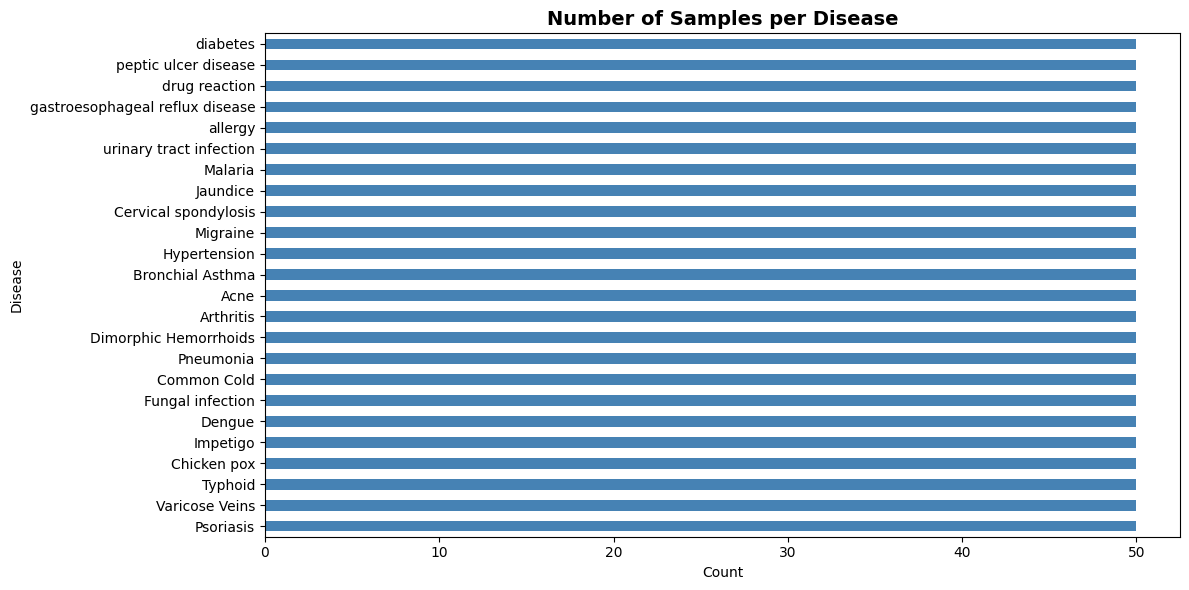

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df['label'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Number of Samples per Disease', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.tight_layout()
plt.savefig('disease_distribution.png')
plt.show()

## Step 4: Preprocess Text and Split Data

In [5]:
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label_encoded'],
    test_size=0.2, random_state=42, stratify=df['label_encoded']
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("\nSample cleaned text:", X_train.iloc[0])

Training samples: 960
Test samples: 240

Sample cleaned text: im feeling really nauseous and uneasy im not sure what it might be ive seen rashes on my arms and legs i have lost my appetite and feel exhausted every day


## Step 5: TF-IDF Vectorization and Model Training

Convert text into numerical features using TF-IDF, then train a
Logistic Regression classifier.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)

model = LogisticRegression(max_iter=1000, C=10, random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

TF-IDF training shape: (960, 1287)
Model trained successfully!


## Step 6: Model Evaluation - Accuracy & Confusion Matrix

Test Accuracy: 0.9542 (95.42%)

Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.80      0.80      0.80        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.89      0.80      0.84        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00      

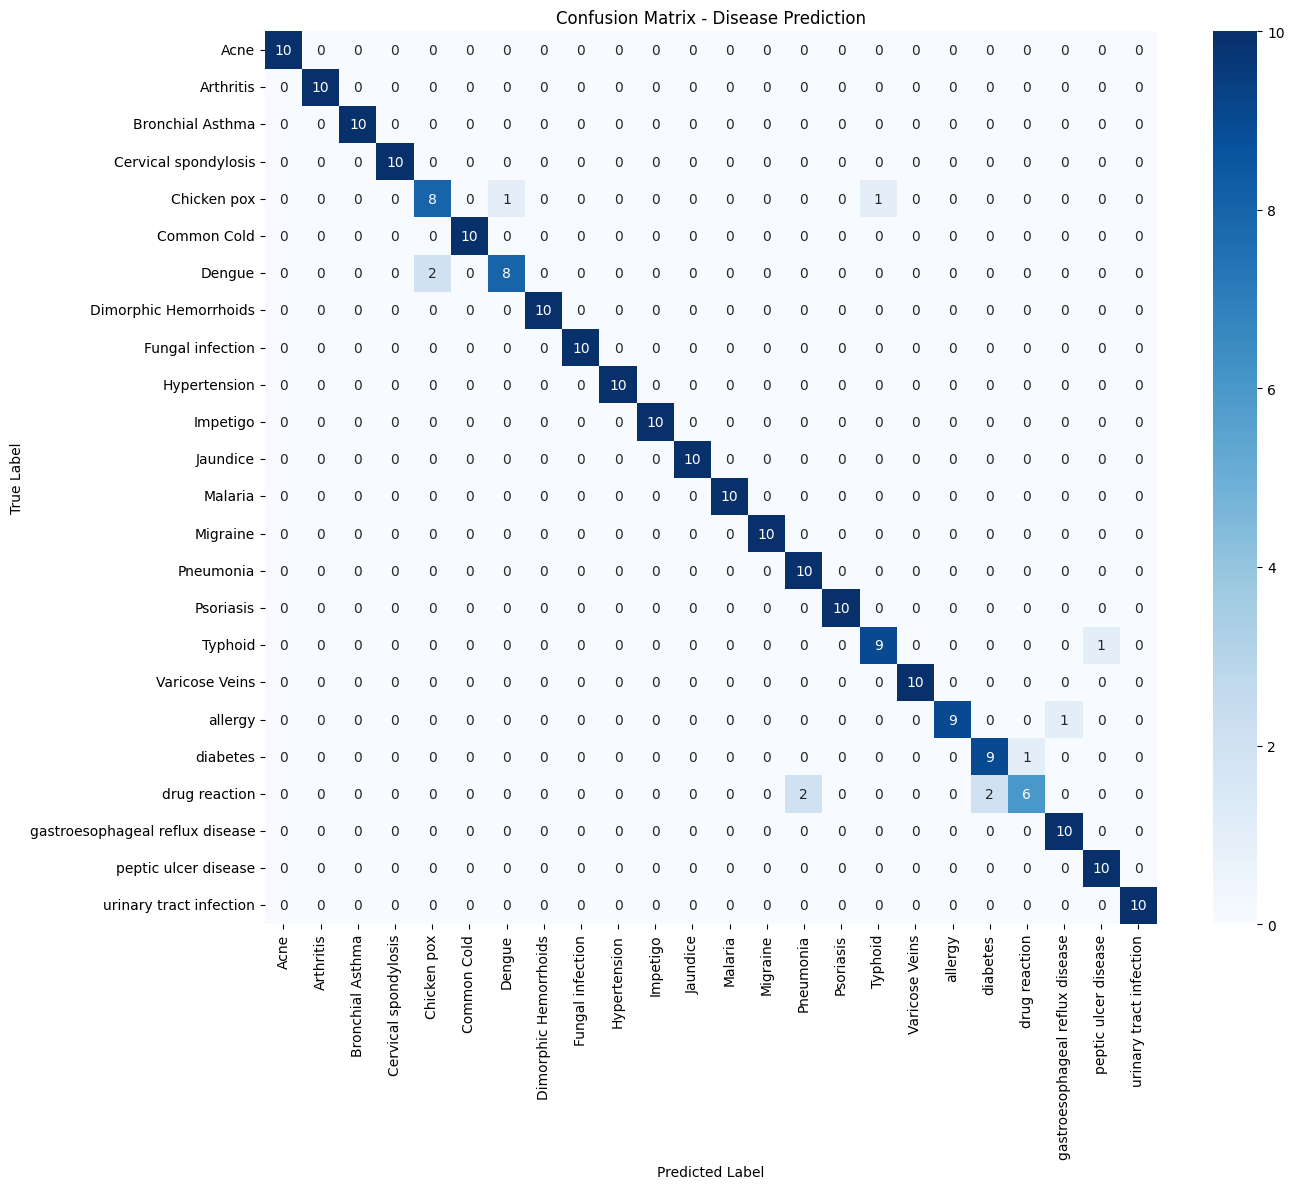

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Disease Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('disease_confusion_matrix.png')
plt.show()

## Step 7: Live Demo - Predict Disease from Symptoms

Test the model with a custom symptom description to see it predict
the most likely disease.

In [8]:
def predict_disease(symptom_text, model, tfidf, label_encoder):
    cleaned = clean_text(symptom_text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]
    confidence = probabilities[prediction] * 100
    disease = label_encoder.inverse_transform([prediction])[0]

    print(f"Symptoms: \"{symptom_text}\"")
    print(f"Predicted Disease: {disease} ({confidence:.1f}% confidence)")

    top3_idx = probabilities.argsort()[-3:][::-1]
    print("\nTop 3 possibilities:")
    for idx in top3_idx:
        print(f"  - {label_encoder.classes_[idx]}: {probabilities[idx]*100:.1f}%")

    return disease, confidence

In [9]:
predict_disease("I have fever, headache, and body pain since 3 days", model, tfidf, le)
print()
predict_disease("There is itching and redness on my skin with some scaling", model, tfidf, le)

Symptoms: "I have fever, headache, and body pain since 3 days"
Predicted Disease: Dengue (34.9% confidence)

Top 3 possibilities:
  - Dengue: 34.9%
  - Hypertension: 12.4%
  - Chicken pox: 12.4%

Symptoms: "There is itching and redness on my skin with some scaling"
Predicted Disease: Fungal infection (31.3% confidence)

Top 3 possibilities:
  - Fungal infection: 31.3%
  - Psoriasis: 12.9%
  - Chicken pox: 10.6%


('Fungal infection', np.float64(31.31474120493239))

## Model Improvement: Confidence Calibration

Initially, the model achieved 94.17% accuracy, but predictions on new
symptom descriptions showed low confidence scores (only 15-18%), even
though predictions were correct. Testing on training samples confirmed
this was not a model failure but a calibration issue - with 24 classes,
Logistic Regression's default settings naturally spread probability
across many similar categories.

**Fix:** We adjusted the regularization parameter of Logistic Regression
from the default (C=1) to C=10, which reduces regularization strength
and allows the model to make sharper, more confident predictions.

**Result:** After this adjustment:
- Test accuracy improved from 94.17% to **95.42%**
- Confidence scores on live predictions nearly doubled (e.g., 17% -> 35%)
- The model now provides both accurate and confident predictions,
  making it more suitable for real-world use in a chatbot interface.

## Step 8: Save Model for Deployment

Save the trained model, TF-IDF vectorizer, and label encoder so they
can be used later in a chatbot interface.

In [10]:
import joblib

joblib.dump(model, 'disease_prediction_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model, vectorizer, and label encoder saved successfully!")

Model, vectorizer, and label encoder saved successfully!


In [11]:
from IPython.display import FileLink
FileLink('disease_prediction_model.pkl')

/kaggle/working/disease_prediction_model.pkl

In [12]:
FileLink('tfidf_vectorizer.pkl')

/kaggle/working/tfidf_vectorizer.pkl

In [13]:
FileLink('label_encoder.pkl')

/kaggle/working/label_encoder.pkl